# Claim Extraction — What Does This Paper Contribute?

## Goal
Extract the main claims and contributions from scientific paper abstracts.
Every paper makes claims — we want to find them automatically.

## Approach
Rule-based extraction using linguistic patterns.
Claim sentences usually contain specific signal words:
- "We propose", "We present", "We introduce"
- "Our model achieves", "outperforms"
- "We show that", "We demonstrate"

## Key Question
Can we automatically identify what a paper claims to contribute?

In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt

## 1. Define Claim Patterns

In [9]:
# Signal phrases that indicate a claim or contribution
claim_patterns = [
    r'we propose',
    r'we present',
    r'we introduce',
    r'we show',
    r'we demonstrate',
    r'we achieve',
    r'we develop',
    r'our model',
    r'our approach',
    r'our method',
    r'outperform',
    r'state.of.the.art',
    r'significantly better',
    r'novel',
    r'new approach',
    r'first to',
]

def extract_claims(text: str, patterns: list) -> list:
    """
    Extract sentences that contain claim signal words.
    
    Args:
        text: Document text
        patterns: List of regex patterns indicating claims
    
    Returns:
        List of claim sentences with their signal words
    """
    sentences = re.split(r"(?<=[.!?])\s+", text)
    claims = []

    for sentence in sentences:
        sentence = sentence.strip()
        if len(sentence) < 20:
            continue

        for pattern in patterns:
            if re.search(pattern, sentence, re.IGNORECASE):
                claims.append({
                    "sentence": sentence,
                    "signal": pattern,
                    "lenght": len(sentence.split())
                })
                break

    return claims

# Test on our paper corpus
papers = [
    {
        "title": "Attention Is All You Need",
        "abstract": "We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. The dominant sequence transduction models are based on complex recurrent or convolutional neural networks. The Transformer allows for significantly more parallelization and achieves state of the art on machine translation tasks. On the WMT 2014 English-to-German translation task, our model achieves 28.4 BLEU, improving over the existing best results by over 2 BLEU."
    },
    {
        "title": "BERT",
        "abstract": "We introduce BERT, a new language representation model. BERT is designed to pre-train deep bidirectional representations from unlabeled text by jointly conditioning on both left and right context in all layers. As a result, the pre-trained BERT model can be fine-tuned with just one additional output layer to create state-of-the-art models for a wide range of tasks. BERT obtains new state-of-the-art results on eleven natural language processing tasks."
    },
    {
        "title": "GPT-4",
        "abstract": "We train GPT-4, an autoregressive language model with 175 billion parameters. GPT-4 achieves strong performance on many NLP tasks in the few-shot setting, sometimes outperforming state-of-the-art fine-tuned models. We demonstrate that scaling up language models greatly improves task-agnostic, few-shot performance."
    },
]

print("Claims extracted per paper:\n")
all_results = []

for paper in papers:
    claims = extract_claims(paper["abstract"], claim_patterns)
    print(f"Paper: {paper["title"]}")
    print(f"Clamis found: {len(claims)}")
    for c in claims:
        print(f" [{c["signal"]}] {c["sentence"][:100]}...")
    print()
    for c in claims:
        all_results.append({"paper": paper["title"], **c})

Claims extracted per paper:

Paper: Attention Is All You Need
Clamis found: 3
 [we propose] We propose a new simple network architecture, the Transformer, based solely on attention mechanisms,...
 [state.of.the.art] The Transformer allows for significantly more parallelization and achieves state of the art on machi...
 [our model] On the WMT 2014 English-to-German translation task, our model achieves 28.4 BLEU, improving over the...

Paper: BERT
Clamis found: 3
 [we introduce] We introduce BERT, a new language representation model....
 [state.of.the.art] As a result, the pre-trained BERT model can be fine-tuned with just one additional output layer to c...
 [state.of.the.art] BERT obtains new state-of-the-art results on eleven natural language processing tasks....

Paper: GPT-4
Clamis found: 2
 [outperform] GPT-4 achieves strong performance on many NLP tasks in the few-shot setting, sometimes outperforming...
 [we demonstrate] We demonstrate that scaling up language models greatly impr

## 2. Visualize Claims

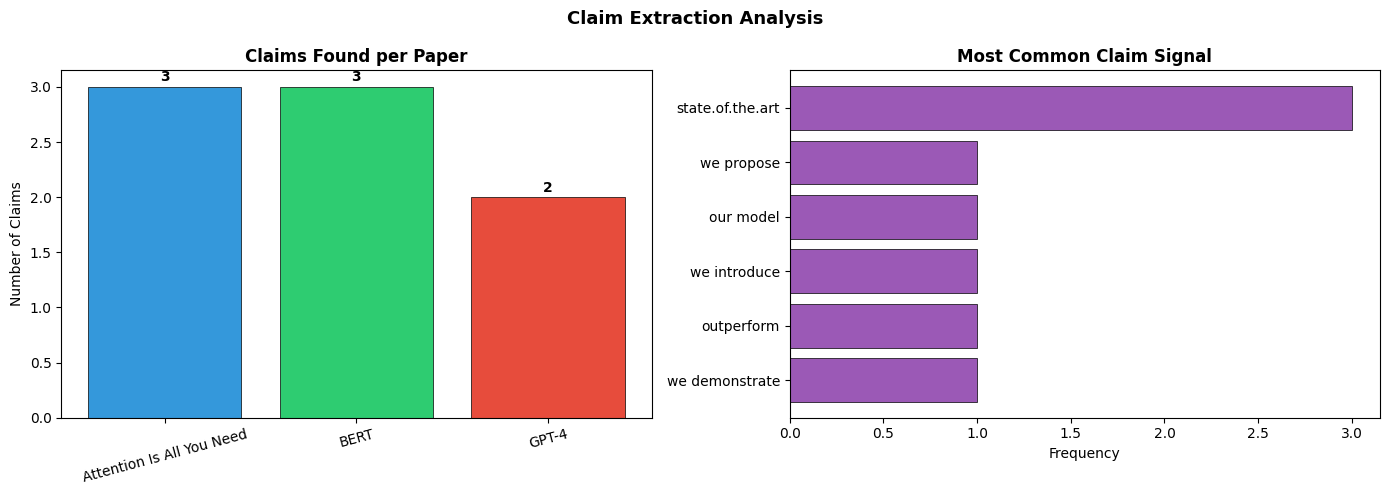

In [14]:
df_claims = pd.DataFrame(all_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Claims per paper
claims_per_paper = df_claims.groupby("paper")["sentence"].count()
bars = axes[0].bar(claims_per_paper.index, claims_per_paper.values,
                  color=["#3498db", "#2ecc71", "#e74c3c"],
                  edgecolor="black", linewidth=0.5)
axes[0].set_title("Claims Found per Paper", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of Claims")
axes[0].tick_params(axis="x", rotation=15)
for bar, val in zip(bars, claims_per_paper.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(val), ha="center", fontweight="bold")

# Chart 2 - Most common signal words
signal_counts = df_claims["signal"].value_counts()
axes[1].barh(signal_counts.index[::-1], signal_counts.values[::-1],
            color="#9b59b6", edgecolor="black", linewidth=0.5)
axes[1].set_title("Most Common Claim Signal", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Frequency")

plt.suptitle("Claim Extraction Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("claim_extraction.png", dpi=300)
plt.show()